In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/refs/heads/main/Data/titanic_disaster.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
df["Age"] = df["Age"].fillna(
    df["Age"].mean()
)

In [5]:
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [6]:
df = df.drop(columns=["Cabin"])

In [8]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

In [9]:
df["Embarked"] = df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

In [10]:
df = df.drop(columns=[
    "PassengerId",
    "Name",
    "Ticket"
])

In [11]:
data = df.values

print(type(data))
print(data.shape)

<class 'numpy.ndarray'>
(891, 8)


In [12]:
X = data[:,1:]
y = data[:,0]

In [13]:
mean = np.mean(X, axis=0)

std = np.std(X, axis=0)

X = (X - mean) / std

In [14]:
print(np.mean(X, axis=0))

[-8.77213254e-17  3.98733297e-17  2.23290646e-16  4.38606627e-17
  5.38289951e-17  3.98733297e-18 -1.39556654e-17]


In [15]:
np.random.seed(42)

indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

In [16]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [17]:
print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


In [18]:
n_features = X_train.shape[1]

In [19]:
w = np.zeros(n_features)

b = 0

In [20]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [21]:
learning_rate = 0.01

epochs = 1000

losses = []

In [22]:
for epoch in range(epochs):

    z = np.dot(X_train, w) + b

    y_pred = sigmoid(z)

    loss = -np.mean(
        y_train*np.log(y_pred+1e-8)
        +
        (1-y_train)*np.log(1-y_pred+1e-8)
    )

    losses.append(loss)

    dw = np.dot(
        X_train.T,
        (y_pred - y_train)
    ) / len(X_train)

    db = np.mean(
        y_pred - y_train
    )

    w = w - learning_rate * dw

    b = b - learning_rate * db

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch} Loss={loss:.4f}"
        )

Epoch 0 Loss=0.6931
Epoch 100 Loss=0.5984
Epoch 200 Loss=0.5476
Epoch 300 Loss=0.5175
Epoch 400 Loss=0.4984
Epoch 500 Loss=0.4854
Epoch 600 Loss=0.4764
Epoch 700 Loss=0.4697
Epoch 800 Loss=0.4648
Epoch 900 Loss=0.4610


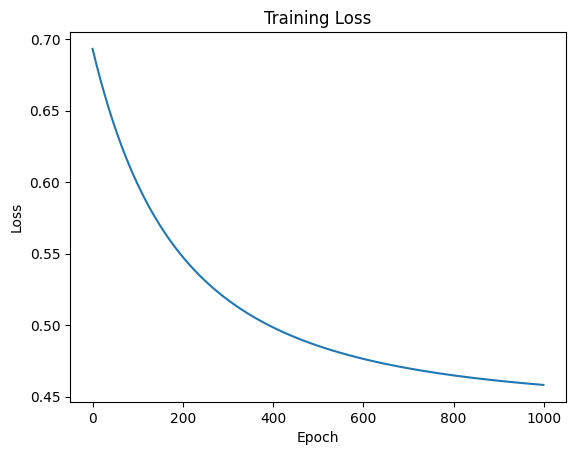

In [23]:
plt.plot(losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [24]:
z = np.dot(X_test,w)+b

y_pred = sigmoid(z)

In [25]:
y_pred = (y_pred >= 0.5).astype(int)

In [26]:
accuracy = np.mean(
    y_pred == y_test
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.8156424581005587
